In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve
import sympy as sp

In [6]:
plt.rcParams["figure.figsize"] = (7,5)
plt.rc('xtick', direction='in')
plt.rc('ytick', direction='in')
plt.rc('font', family='serif')

s_size = 5
latex_size = 20
scat = "scatter"
alp = 0.3
mpl.rcParams['axes.xmargin'] = 0
mpl.rcParams["xtick.minor.visible"] =  True
mpl.rcParams["ytick.minor.visible"] =  True
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['xtick.minor.width'] = 1.0

mpl.rcParams['ytick.minor.size'] = 5
mpl.rcParams['ytick.minor.width'] = 1.0
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['ytick.major.width'] = 1.5

mpl.rcParams.update({"axes.grid" : True, "grid.color": "black","grid.alpha": "0.3" })
mpl.rcParams['font.size'] = 16
plt.rc('legend', loc='best',fancybox=True,markerscale=2) 

In [7]:
# Read the data
data_files = [ 'CHWtill_hjj_big_data_data_aug.csv'
]
df_chw_hjj = pd.concat(
    [pd.read_csv(f) for f in data_files])
#df_chw_hjj.reset_index(drop=True, inplace=True)
print(df_chw_hjj.keys())

Index(['jet0Pt', 'jet0Eta', 'jet0Phi', 'jet1Pt', 'jet1Eta', 'jet1Phi', 'hPt',
       'hEta', 'hPhi', 'deltaphi', 'sign_w'],
      dtype='object')


In [8]:
df_chw_hjj

,jet0Pt,jet0Eta,jet0Phi,jet1Pt,jet1Eta,jet1Phi,hPt,hEta,hPhi,deltaphi,sign_w
0,1.672154,-1.843204,-2.729061,0.453930,2.680678,-2.133047,2.063609,-0.203925,0.536326,-0.596014,-1.0
1,0.838243,2.420060,0.634051,0.654418,-3.925637,-1.472383,0.755615,-3.366255,2.935448,2.106434,1.0
2,1.069747,-3.010563,2.193521,0.607195,3.378601,-2.764860,1.352552,2.252185,-0.497576,-1.324804,-1.0
3,0.955432,-1.819065,-2.268580,0.690238,2.735088,2.150509,1.003968,2.890846,0.154654,1.864097,1.0
4,1.739630,2.422367,2.142933,1.025206,-1.822045,0.927030,2.305829,1.977988,-1.428701,1.215903,1.0
...,...,...,...,...,...,...,...,...,...,...,...
307643,1.637737,2.061481,-1.836928,0.879578,-3.351331,2.667458,1.691415,-0.789086,0.770856,1.778800,1.0
307644,0.863166,-2.054948,-2.210073,0.528735,3.961637,1.956576,0.742186,0.297952,0.276821,2.116537,-1.0
307645,1.436319,0.445910,0.331807,0.763661,-2.707941,2.918419,0.884151,0.386789,-2.337280,-2.586612,-1.0
307646,0.768070,-2.647665,-2.000775,0.359936,0.542979,0.403940,0.556790,-0.378414,1.590189,-2.404715,-1.0


In [9]:
df_chw_hjj.jet0Phi - df_chw_hjj.jet1Phi

0        -0.596014
1         2.106434
2         4.958381
3        -4.419089
4         1.215903
            ...   
307643   -4.504385
307644   -4.166649
307645   -2.586612
307646   -2.404715
307647    1.623394
Length: 307648, dtype: float64

In [10]:
filtered_df = df_chw_hjj.dropna()
print(len(filtered_df), len(df_chw_hjj))

307648 307648


In [11]:

print(df_chw_hjj['sign_w'].unique())


[-1.  1.]


In [12]:
def plot_hist(df, column, weight=None, bins=30, xmin=None, xmax=None, label=None):
    data = df[column].values
    weights = df[weight].values if weight else None
    
    if xmin is None:
        xmin = data.min()
    if xmax is None:
        xmax = data.max()
    
    bin_edges = np.linspace(xmin, xmax, bins + 1)
    
    plt.hist(data, bins=bin_edges, weights=weights, 
             color='steelblue', 
             edgecolor='black',
             alpha=0.7,
             label=label)  # Add label here
    plt.xlabel(column)
    plt.ylabel('No. of Events')
    plt.grid(False)
    plt.tight_layout()
    if label:
        plt.legend()  # Show legend if label is provided
    return plt


In [13]:

def plot_diff_xsec(df, column, weight=None, bins=30, xmin=None, xmax=None):
    data = df[column].values
    weights = df[weight].values if weight else None
    
    # Determine range
    if xmin is None:
        xmin = data.min()
    if xmax is None:
        xmax = data.max()
    
    bin_edges = np.linspace(xmin, xmax, bins + 1)
    

    counts, _ = np.histogram(data, bins=bin_edges, weights=weights)
    
   
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_widths = np.diff(bin_edges)
    
    # Compute differential cross section: dσ/dX
    d_sigma = counts / bin_widths
    
    ## What is the total cross section and luminosity and eff.???

    # Normalize to unity
    total = np.sum(d_sigma * bin_widths)
    if total > 0:
        d_sigma /= total
    
    # Plot as bar chart
    plt.bar(bin_centers, d_sigma, width=bin_widths,
            color='steelblue', alpha=0.7)
    
    plt.xlabel(column)
    plt.ylabel(f'Normalized dσ/d{column} [fb/unit]')
    plt.grid(False)
    plt.tight_layout()
    
    return plt


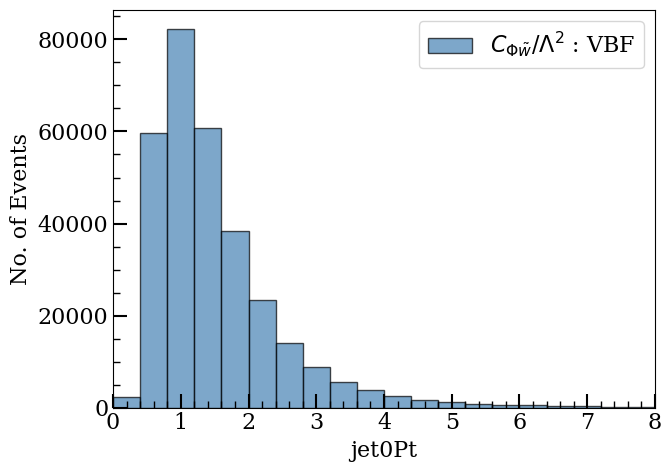

In [14]:
# 1. Basic histogram
plot_hist(df_chw_hjj, 'jet0Pt', bins=20, xmin=0.,xmax=8, label=r'$C_{\Phi \tilde{w}}/\Lambda^2$ : VBF')
#plot_hist(df_chw_hjj, 'jet1Pt', bins=20, xmin=0.,xmax=8, label=r'$C_{\Phi \tilde{w}}/\Lambda^2$ : VBF')

plt.show()

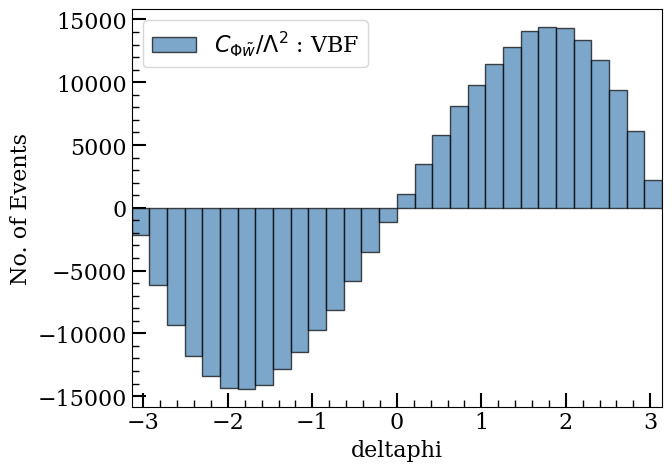

In [15]:
plot_hist(df_chw_hjj, 'deltaphi', bins=30, weight='sign_w', label=r'$C_{\Phi \tilde{w}}/\Lambda^2$ : VBF')
plt.show()
#plt.savefig('')


In [16]:
features = [
    'jet0Pt','jet0Eta','jet0Phi',
    'jet1Pt','jet1Eta','jet1Phi',
    'hPt','hEta','hPhi',
    'deltaphi'
]

X = df_chw_hjj[features].values
y = np.where(df_chw_hjj['sign_w'] > 0, 1, 0)  # + → 1, − → 0
weights = df_chw_hjj['sign_w'].values         # sign values as it is 
print(y)

[0 1 0 ... 0 0 1]


In [17]:
scaler = StandardScaler()
X = scaler.fit_transform(X)

In [18]:
X

array([[ 0.15529056, -0.79598551, -1.50418174, ..., -0.12775528,
         0.29608254, -0.32853451],
       [-0.68012217,  1.04510001,  0.34947103, ..., -2.10889723,
         1.62053381,  1.16110738],
       [-0.44820123, -1.30010797,  1.2090071 , ...,  1.41095287,
        -0.27469038, -0.73025782],
       ...,
       [-0.0809693 ,  0.1925657 ,  0.18288271, ...,  0.24231645,
        -1.29031128, -1.42579086],
       [-0.75042135, -1.14339079, -1.10277059, ..., -0.23706943,
         0.87787457, -1.32552574],
       [ 0.52886507,  0.73987865,  0.03033322, ..., -0.43315602,
         1.65496404,  0.8948461 ]])

In [19]:
class VBFDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


In [20]:
dataset = VBFDataset(X, y)
loader = DataLoader(dataset, batch_size=256, shuffle=True)


Note: The interference term of SM and EFT is antisymmetric => odd upcer CP. tanh being an odd function performs better than ReLU 

In [21]:
class CPClassifier(nn.Module):
    def __init__(self, n_inputs):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_inputs, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    #simple forward pass to all sequential layers until architectures like ResNets
    #(skip connections), transformers, or networks that change behavior during inference

    def forward(self, x):
        return self.net(x).squeeze()


In [22]:
device = torch.device("cpu")
model = CPClassifier(len(features))
print(model)


CPClassifier(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=1, bias=True)
    (5): Sigmoid()
  )
)


In [23]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

epochs = 30


In [24]:
train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    train_losses.append(avg_loss)

    print(f"Epoch {epoch} | Loss {avg_loss:.5f}")



Epoch 0 | Loss 0.23816
Epoch 1 | Loss 0.20149
Epoch 2 | Loss 0.19474
Epoch 3 | Loss 0.19313
Epoch 4 | Loss 0.19270
Epoch 5 | Loss 0.19243
Epoch 6 | Loss 0.19223
Epoch 7 | Loss 0.19213
Epoch 8 | Loss 0.19193
Epoch 9 | Loss 0.19186
Epoch 10 | Loss 0.19173
Epoch 11 | Loss 0.19157
Epoch 12 | Loss 0.19148
Epoch 13 | Loss 0.19134
Epoch 14 | Loss 0.19129
Epoch 15 | Loss 0.19118
Epoch 16 | Loss 0.19116
Epoch 17 | Loss 0.19107
Epoch 18 | Loss 0.19101
Epoch 19 | Loss 0.19092
Epoch 20 | Loss 0.19096
Epoch 21 | Loss 0.19090
Epoch 22 | Loss 0.19087
Epoch 23 | Loss 0.19084
Epoch 24 | Loss 0.19085
Epoch 25 | Loss 0.19080
Epoch 26 | Loss 0.19076
Epoch 27 | Loss 0.19076
Epoch 28 | Loss 0.19071
Epoch 29 | Loss 0.19069


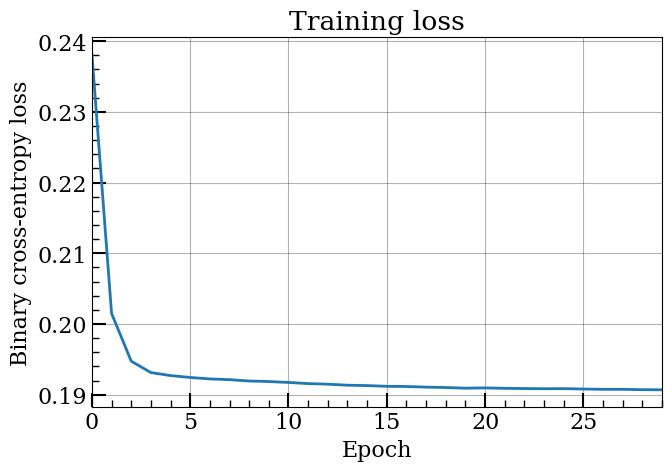

In [25]:

plt.plot(train_losses, lw=2)
plt.xlabel("Epoch")
plt.ylabel("Binary cross-entropy loss")
plt.title("Training loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Constructing the CP-odd observable

In [26]:
with torch.no_grad():
    X_tensor = torch.tensor(X, dtype=torch.float32)
    P_plus = model(X_tensor).numpy()

O_NN = 2.0 * P_plus - 1.0    # Same as Eq.(8) 


In [27]:
O_NN.min()

-0.9923866

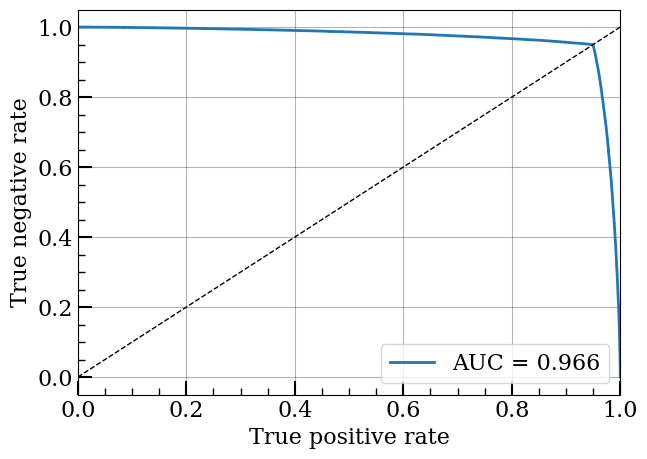

In [28]:
y_true = y
y_score = P_plus

fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)
plt.plot(tpr, 1 - fpr, lw=2,
         label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], 'k--', lw=1)

plt.xlabel("True positive rate")
plt.ylabel("True negative rate")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
def plot_ONN_distribution(O_NN, sign_w, bins=30):
    bin_edges = np.linspace(-1, 1, bins + 1)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths = np.diff(bin_edges)

    hist = np.zeros(bins)

    for i in range(bins):
        mask = (O_NN >= bin_edges[i]) & (O_NN < bin_edges[i+1])
        hist[i] = np.sum(sign_w[mask])   #weighted by interference sign

    plt.figure(figsize=(7,5))
    plt.bar(
        bin_centers,
        hist,
        width=bin_widths,
        color='steelblue',
        alpha=0.8
    )
    plt.axhline(0, color='black', lw=1)

    plt.xlabel(r'$O_{\rm NN}$')
    plt.ylabel(r'No. of Events')
    plt.title(r'ML-constructed CP-odd observable')
    plt.tight_layout()
    plt.show()


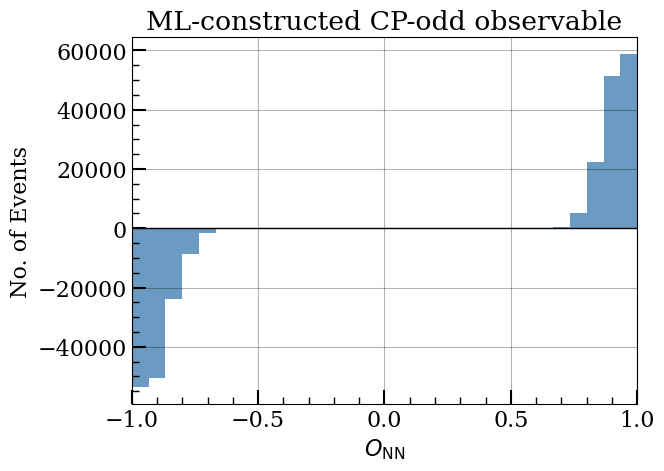

In [30]:
plot_ONN_distribution(O_NN, df_chw_hjj['sign_w'].values)

In [31]:
from IPython.display import Math
A_NN = np.mean(df_chw_hjj['sign_w'].values * O_NN)
A_trad = np.mean(df_chw_hjj['sign_w'].values * np.sin(df_chw_hjj['deltaphi'].values))

print(rf'Av. O_NN_CP: {A_NN}')
print(rf'Av Delta Phi: {A_trad}')



Av. O_NN_CP: 0.8150285211923959
Av Delta Phi: 0.698825728200129


## Symbolic Regression

PYSR: https://www.youtube.com/watch?v=q6tjKXmhiMs  Another 
https://www.youtube.com/watch?v=HKJB0Bjo6tQ <br>  Symbolic Models from Deep Learning
with Inductive Biases https://arxiv.org/pdf/2006.11287

In [32]:
m_h = 125.0

df_chw_hjj['deltaeta'] = df_chw_hjj['jet0Eta'] -  df_chw_hjj['jet1Eta']

df_chw_hjj['xj0'] = df_chw_hjj['jet0Pt'] / m_h
df_chw_hjj['xj1'] = df_chw_hjj['jet1Pt'] / m_h


# inv mass calcualtion =============> mjj^2=2 pT0 pT1 (cosh(eta_0 − eta_1)  − cos(phi_0 - phi_1)) 

deta = df_chw_hjj['jet0Eta'] - df_chw_hjj['jet1Eta']
dphi = df_chw_hjj['jet0Phi'] - df_chw_hjj['jet1Phi']
dphi = (dphi + np.pi) % (2 * np.pi) - np.pi  # Wrap delta phi [-pi , + pi]

m2 = 2.0 * df_chw_hjj['jet0Pt'] * df_chw_hjj['jet1Pt'] * (np.cosh(deta) - np.cos(dphi))
df_chw_hjj['m_jj'] = np.sqrt(np.clip(m2, 0, None))


In [33]:
df_chw_hjj

,jet0Pt,jet0Eta,jet0Phi,jet1Pt,jet1Eta,jet1Phi,hPt,hEta,hPhi,deltaphi,sign_w,deltaeta,xj0,xj1,m_jj
0,1.672154,-1.843204,-2.729061,0.453930,2.680678,-2.133047,2.063609,-0.203925,0.536326,-0.596014,-1.0,-4.523882,0.013377,0.003631,8.290355
1,0.838243,2.420060,0.634051,0.654418,-3.925637,-1.472383,0.755615,-3.366255,2.935448,2.106434,1.0,6.345697,0.006706,0.005235,17.699143
2,1.069747,-3.010563,2.193521,0.607195,3.378601,-2.764860,1.352552,2.252185,-0.497576,-1.324804,-1.0,-6.389164,0.008558,0.004858,19.656987
3,0.955432,-1.819065,-2.268580,0.690238,2.735088,2.150509,1.003968,2.890846,0.154654,1.864097,1.0,-4.554152,0.007643,0.005522,7.940763
4,1.739630,2.422367,2.142933,1.025206,-1.822045,0.927030,2.305829,1.977988,-1.428701,1.215903,1.0,4.244412,0.013917,0.008202,11.095987
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307643,1.637737,2.061481,-1.836928,0.879578,-3.351331,2.667458,1.691415,-0.789086,0.770856,1.778800,1.0,5.412812,0.013102,0.007037,17.990380
307644,0.863166,-2.054948,-2.210073,0.528735,3.961637,1.956576,0.742186,0.297952,0.276821,2.116537,-1.0,-6.016585,0.006905,0.004230,13.699389
307645,1.436319,0.445910,0.331807,0.763661,-2.707941,2.918419,0.884151,0.386789,-2.337280,-2.586612,-1.0,3.153851,0.011491,0.006109,5.254183
307646,0.768070,-2.647665,-2.000775,0.359936,0.542979,0.403940,0.556790,-0.378414,1.590189,-2.404715,-1.0,-3.190644,0.006145,0.002879,2.672048


In [34]:
features_SR= ['jet0Pt','jet0Eta','jet0Phi',
              'jet1Pt','jet1Eta','jet1Phi',
              'hPt','hEta','hPhi',
              'deltaphi','deltaeta','m_jj']


X_SR = df_chw_hjj[features_SR].values
y_SR = np.where(df_chw_hjj['sign_w'] > 0, 1, 0)  # + → 1, − → 0
weights_SR = df_chw_hjj['sign_w'].values         # sign values as it is 
print(X_SR.shape, y_SR)

(307648, 12) [0 1 0 ... 0 0 1]


In [35]:
X_SR = scaler.fit_transform(X_SR)
# --- convert to torch ---
X_SR = torch.tensor(X_SR, dtype=torch.float32)
y_SR = torch.tensor(y_SR, dtype=torch.float32)


In [36]:
dataset_SR = torch.utils.data.TensorDataset(X_SR, y_SR)
loader_SR = DataLoader(dataset_SR, batch_size=256, shuffle=True)


## Symbolic Regression Model ---> Symbolnet

In [37]:
def math_operation(x, y=None, op=None, eps=1e-6):
    # uniary operators
    if op == "identity":
        return x
    elif op == "sin":
        return torch.sin(x)

    elif op == "tanh":
        return torch.tanh(x)
    # binary operators
    elif op == "+":
        return x + y

    elif op == "*":
        return x * y

    elif op == "/":
        return x / (y + eps)

    else:
        raise ValueError(f"Unknown operator {op}")


In [38]:
class SymbolicLayer(nn.Module):
    """
      z = W x + b
      phi = g(z)
      f_theta(x) = A phi + b_out
    """
    def __init__(self, n_inputs, operators, num_operators):
        super().__init__()

        unary_ops, binary_ops = operators
        n_unary, n_binary = num_operators

        # Assign operators per node
        self.unary_fns  = [unary_ops[i % len(unary_ops)] for i in range(n_unary)]
        self.binary_fns = [binary_ops[i % len(binary_ops)] for i in range(n_binary)]

        # Linear maps for symbolic arguments
        self.W_unary = nn.Linear(n_inputs, n_unary, bias=True)
        self.W_bin1  = nn.Linear(n_inputs, n_binary, bias=True)
        self.W_bin2  = nn.Linear(n_inputs, n_binary, bias=True)

        #matrix A
        self.A_unary  = nn.Parameter(torch.randn(n_unary))
        self.A_binary = nn.Parameter(torch.randn(n_binary))

        # Output bias
        self.b_out = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        phi = []

        # ----- Unary operators -----
        z = self.W_unary(x)
        for i, op in enumerate(self.unary_fns):
            phi.append(math_operation(z[:, i], op=op))

        # ----- Binary operators -----
        z1 = self.W_bin1(x)
        z2 = self.W_bin2(x)
        for i, op in enumerate(self.binary_fns):
            phi.append(math_operation(z1[:, i], z2[:, i], op=op))

        phi = torch.stack(phi, dim=1)  # (batch, n_phi)

        A = torch.cat([self.A_unary, self.A_binary])
        f_theta = phi @ A + self.b_out

        return f_theta


In [39]:
class SymbolNet(nn.Module):
    def __init__(self, n_inputs, operators, num_operators):
        super().__init__()
        self.symbolic = SymbolicLayer(
            n_inputs,
            operators[0],
            num_operators[0]
        )

    def forward(self, x):
        return self.symbolic(x)


In [40]:
def output_score(model, x):
    return model(x)

def p_hat(model, x):
    return torch.sigmoid(output_score(model, x))


In [41]:
def symbolic_bce_loss(model, x, y, lambda_A=1e-3):
    """
    L = -log p_hat(x) + lambda * ||A||_1
    """
    f_theta = model(x).view(-1)
    y = y.view(-1)

    p = torch.sigmoid(f_theta)

    # --- BCE-----------------------
    bce = F.binary_cross_entropy(p, y)

    # Sparsity on symbolic combinations
    layer = model.symbolic
    A_penalty = (
        torch.sum(torch.abs(layer.A_unary)) +
        torch.sum(torch.abs(layer.A_binary))
    )

    return bce + lambda_A * A_penalty


In [42]:
operators = [[['sin','tanh'], ['+','*', '/']]]

# number of unary and binary operators per hidden symbolic layer
num_operators = [[2, 3]]


model = SymbolNet(
    n_inputs=X_SR.shape[1],
    operators=operators,
    num_operators=num_operators
)
print(model)


SymbolNet(
  (symbolic): SymbolicLayer(
    (W_unary): Linear(in_features=12, out_features=2, bias=True)
    (W_bin1): Linear(in_features=12, out_features=3, bias=True)
    (W_bin2): Linear(in_features=12, out_features=3, bias=True)
  )
)


In [43]:
model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)

for epoch in range(1, 31):

    epoch_loss = 0.0
    all_scores = []
    all_labels = []

    pbar = tqdm(loader_SR, desc=f"Epoch {epoch}", leave=False)

    for xb, yb in pbar:
        yb = yb.view(-1)

        loss = symbolic_bce_loss(model, xb, yb, lambda_A=0)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # --- collect for AUC ---
        with torch.no_grad():
            scores = model(xb).view(-1)
            all_scores.append(scores.cpu())
            all_labels.append(yb.cpu())

        pbar.set_postfix(loss=loss.item())

    # --- epoch summary ---
    scores = torch.cat(all_scores).numpy()
    labels = torch.cat(all_labels).numpy()

    auc = roc_auc_score(labels, scores)
    epoch_loss /= len(loader_SR)

    if epoch % 2 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | Loss = {epoch_loss:.4e} | AUC = {auc:.4f}")


Epoch 001 | Loss = 2.8251e-01 | AUC = 0.9556


Epoch 002 | Loss = 2.0870e-01 | AUC = 0.9611


Epoch 004 | Loss = 2.0130e-01 | AUC = 0.9621


Epoch 006 | Loss = 2.0187e-01 | AUC = 0.9622


Epoch 008 | Loss = 1.9945e-01 | AUC = 0.9624


...

Epoch 022 | Loss = 1.9935e-01 | AUC = 0.9625


Epoch 024 | Loss = 1.9913e-01 | AUC = 0.9626


Epoch 026 | Loss = 1.9923e-01 | AUC = 0.9625


Epoch 028 | Loss = 1.9914e-01 | AUC = 0.9626


Epoch 030 | Loss = 1.9911e-01 | AUC = 0.9626


In [46]:
def extract_symbolic_expression_fast(
    model,
    feature_names,
    A_threshold=1e-2,
    W_threshold=1e-3,
    b_threshold=1e-3
):
    """
    FAST extraction of f_theta(x) as a SymPy expression.
    No simplify() call.
    """

    layer = model.symbolic

    # Symbols (ordered!)
    x_syms = sp.symbols(feature_names)
    x_map = dict(zip(feature_names, x_syms))

    expr = sp.Integer(0)

    # ---------- Unary terms ----------
    W = layer.W_unary.weight.detach().cpu().numpy()
    b = layer.W_unary.bias.detach().cpu().numpy()
    A = layer.A_unary.detach().cpu().numpy()

    for i, op in enumerate(layer.unary_fns):
        if abs(A[i]) < A_threshold:
            continue

        lin = sp.Integer(0)
        for j, fname in enumerate(feature_names):
            wij = W[i, j]
            if abs(wij) > W_threshold:
                lin += sp.Float(wij) * x_map[fname]

        bi = b[i]
        if abs(bi) > b_threshold:
            lin += sp.Float(bi)

        if op == 'sin':
            term = sp.sin(lin)
        elif op == 'tanh':
            term = sp.tanh(lin)
        else:
            raise ValueError(op)

        expr += sp.Float(A[i]) * term

    # ---------- Binary terms ----------
    W1 = layer.W_bin1.weight.detach().cpu().numpy()
    W2 = layer.W_bin2.weight.detach().cpu().numpy()
    b1 = layer.W_bin1.bias.detach().cpu().numpy()
    b2 = layer.W_bin2.bias.detach().cpu().numpy()
    A = layer.A_binary.detach().cpu().numpy()

    for i, op in enumerate(layer.binary_fns):
        if abs(A[i]) < A_threshold:
            continue

        lin1 = sp.Integer(0)
        lin2 = sp.Integer(0)

        for j, fname in enumerate(feature_names):
            w1 = W1[i, j]
            w2 = W2[i, j]
            if abs(w1) > W_threshold:
                lin1 += sp.Float(w1) * x_map[fname]
            if abs(w2) > W_threshold:
                lin2 += sp.Float(w2) * x_map[fname]

        if abs(b1[i]) > b_threshold:
            lin1 += sp.Float(b1[i])
        if abs(b2[i]) > b_threshold:
            lin2 += sp.Float(b2[i])

        if op == '*':
            term = lin1 * lin2
        elif op == '+':
            term = lin1 + lin2
        elif op == '/':
            term = lin1 / lin2
        else:
            raise ValueError(op)

        expr += sp.Float(A[i]) * term

    # ---------- Output bias ----------
    bout = layer.b_out.item()
    if abs(bout) > b_threshold:
        expr += sp.Float(bout)

    return expr


In [47]:
sym_expr = extract_symbolic_expression_fast(
    model,
    feature_names=features_SR,
    A_threshold=1e-2
)

sym_expr   # returns instantly


-0.082032*deltaeta + 2.70876*deltaphi - 0.00518774*hEta + 0.483679*hPhi + 0.0970561*hPt + 0.0949094*jet0Eta - 0.0467639*jet0Phi - 0.10857*jet0Pt - 0.0525313*jet1Eta - 0.503341*jet1Phi - 0.110864*jet1Pt + 0.00171246*m_jj + 0.135695*(-0.0849494*deltaeta - 3.84767*deltaphi + 0.130492*hEta - 0.115256*hPhi + 0.0875289*hPt - 0.0389705*jet0Eta - 0.0263633*jet0Phi - 0.0599492*jet0Pt - 0.0472731*jet1Eta + 0.0795194*jet1Phi - 0.023619*jet1Pt + 0.0480599*m_jj - 0.0768038)*(0.153562*deltaeta - 0.17432*deltaphi - 0.0250552*hEta - 0.0255427*hPhi - 3.77312*hPt - 0.0493645*jet0Eta - 0.00946626*jet0Phi + 2.78508*jet0Pt - 0.0206851*jet1Eta + 0.0170107*jet1Phi - 1.28844*jet1Pt + 0.100488*m_jj - 1.83208) + 1.06097*sin(0.0475857*deltaeta + 4.28395*deltaphi + 0.0438121*hEta - 0.079227*hPhi + 0.128907*hPt - 0.0725856*jet0Eta + 0.0269304*jet0Phi - 0.0876215*jet0Pt + 0.0788169*jet1Eta + 0.0349983*jet1Phi - 0.0692674*jet1Pt + 0.0385892*m_jj - 0.0387532) - 0.820716*tanh(-0.0679761*deltaeta + 1.40264*deltaphi + 0

In [48]:
f_expr = sp.lambdify(
    sp.symbols(features_SR),
    sym_expr,
    modules=["numpy"]
)

X_np = X_SR.numpy()
f_theta_expr = f_expr(*[X_np[:, i] for i in range(X_np.shape[1])])

with torch.no_grad():
    f_theta_nn = model(X_SR).numpy()

print("Max |NN - expr| =", np.max(np.abs(f_theta_nn - f_theta_expr)))


Max |NN - expr| = 6.198883e-05


In [66]:
expr = sp.factor(sp.together(sym_expr)).evalf(6)

latex_expr = sp.latex(expr)
print(latex_expr)


- \frac{9.05168 \cdot 10^{-248} \left(1.10534 \cdot 10^{318} deltaeta^{3} + 4.87925 \cdot 10^{319} deltaeta^{2} deltaphi - 1.91755 \cdot 10^{318} deltaeta^{2} hEta + 1.55066 \cdot 10^{318} deltaeta^{2} hPhi - 2.8216 \cdot 10^{319} deltaeta^{2} hPt + 9.39478 \cdot 10^{317} deltaeta^{2} jet0Eta + 2.78129 \cdot 10^{317} deltaeta^{2} jet0Phi + 2.06925 \cdot 10^{319} deltaeta^{2} jet0Pt - 5.04029 \cdot 10^{317} deltaeta^{2} jet1Eta - 9.40098 \cdot 10^{317} deltaeta^{2} jet1Phi - 8.97296 \cdot 10^{318} deltaeta^{2} jet1Pt + 1.14334 \cdot 10^{317} deltaeta^{2} m_{jj} + 3.88969 \cdot 10^{319} deltaeta^{2} - 5.76059 \cdot 10^{319} deltaeta deltaphi^{2} - 7.94569 \cdot 10^{318} deltaeta deltaphi hEta + 3.19535 \cdot 10^{317} deltaeta deltaphi hPhi - 1.22477 \cdot 10^{321} deltaeta deltaphi hPt + 1.81129 \cdot 10^{319} deltaeta deltaphi jet0Eta - 3.33711 \cdot 10^{318} deltaeta deltaphi jet0Phi + 9.00844 \cdot 10^{320} deltaeta deltaphi jet0Pt - 5.02938 \cdot 10^{319} deltaeta deltaphi jet1Eta + 

In [53]:
# Symbols in the same order as features_SR
sym_vars = sp.symbols(features_SR)

# Lambdify (safe: no string parsing anymore)
f_expr = sp.lambdify(sym_vars, sym_expr, modules="numpy")


In [54]:
f_theta_vals = f_expr(*[X_np[:, i] for i in range(X_np.shape[1])])

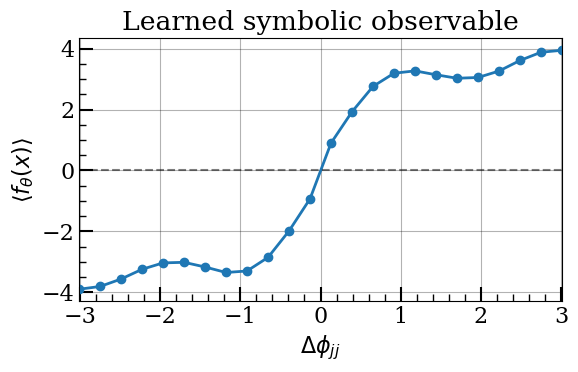

In [55]:
def profile_mean(x, y, bins):
    centers = 0.5 * (bins[:-1] + bins[1:])
    mean = np.full(len(centers), np.nan)

    for i in range(len(centers)):
        mask = (x >= bins[i]) & (x < bins[i+1])
        if np.any(mask):
            mean[i] = np.mean(y[mask])

    return centers, mean

bins = np.linspace(-np.pi, np.pi, 25)

phi_centers, f_mean = profile_mean(dphi, f_theta_vals, bins)

plt.figure(figsize=(6,4))
plt.plot(phi_centers, f_mean, marker='o', lw=2)
plt.axhline(0, color='k', ls='--', alpha=0.5)

plt.xlabel(r'$\Delta\phi_{jj}$')
plt.ylabel(r'$\langle f_\theta(x) \rangle$')
plt.title('Learned symbolic observable')

plt.tight_layout()
plt.show()


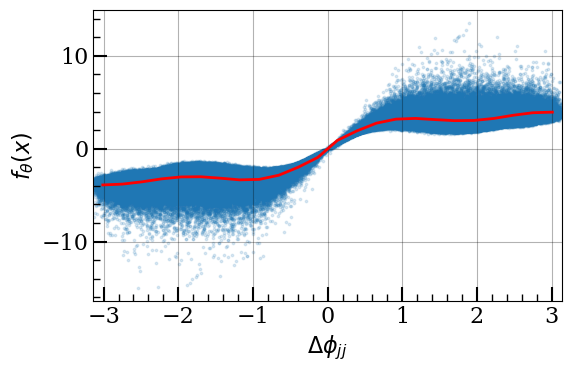

In [58]:
plt.figure(figsize=(6,4))
plt.scatter(dphi, f_theta_vals, s=3, alpha=0.15, rasterized=True)
plt.plot(phi_centers, f_mean, color='red', lw=2)

plt.xlabel(r'$\Delta\phi_{jj}$')
plt.ylabel(r'$f_\theta(x)$')
plt.tight_layout()
plt.show()
